In [18]:
!pip install tensorflow

In [1]:
# ============================================================
# Neural Network Optimization & Generalization (MNIST)
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist

np.random.seed(42)

In [2]:
# =========================
# 2. LOAD & PREPARE DATA
# =========================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

enc = OneHotEncoder(sparse_output=False)
y_train = enc.fit_transform(y_train.reshape(-1,1))
y_test = enc.transform(y_test.reshape(-1,1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


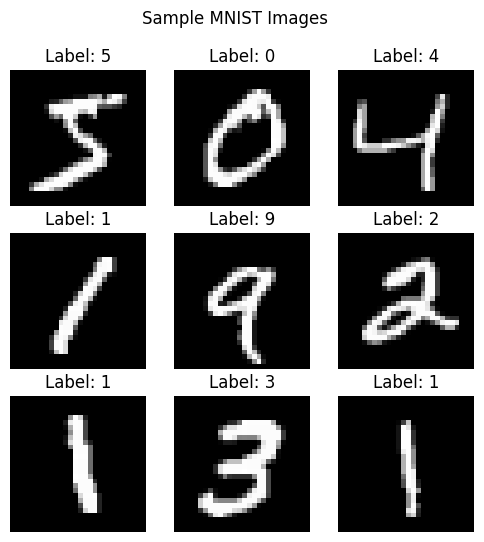

In [3]:
# =========================
# 🔍 VISUALIZATION 1: SAMPLE IMAGES
# =========================
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

In [4]:
# =========================
# 🔹 TRAIN-VALIDATION SPLIT
# =========================
val_size = 10000
X_val = X_train[:val_size]
y_val = y_train[:val_size]

X_train_small = X_train[val_size:]
y_train_small = y_train[val_size:]


In [5]:
# ============================================================
# EXPERIMENTATION MODES
# ============================================================

MODE = "good_fit"

configs = {
    "underfitting": {"hidden_size": 16, "lr": 0.1, "epochs": 20},
    "good_fit": {"hidden_size": 64, "lr": 0.1, "epochs": 50},
    "overfitting": {"hidden_size": 128, "lr": 0.1, "epochs": 150},
    "slow_learning": {"hidden_size": 64, "lr": 0.01, "epochs": 50}
}

config = configs[MODE]

hidden_size = config["hidden_size"]
lr = config["lr"]
epochs = config["epochs"]

print(f"\nRunning Mode: {MODE}")
print(config)


Running Mode: good_fit
{'hidden_size': 64, 'lr': 0.1, 'epochs': 50}


In [6]:
# =========================
# MODEL INIT
# =========================
input_size = 784
output_size = 10

# He Initialization
w1 = np.random.randn(input_size, hidden_size) * np.sqrt(2/input_size)
w2 = np.random.randn(hidden_size, output_size) * np.sqrt(2/hidden_size)

# Bias
b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

In [7]:
# =========================
# ACTIVATIONS
# =========================
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)

In [8]:
# =========================
# FORWARD
# =========================
def forward(X):
    z1 = np.dot(X, w1) + b1
    a1 = relu(z1)
    z2 = np.dot(a1, w2) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

In [9]:
# =========================
# LOSS
# =========================
def compute_loss(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))


In [10]:
# =========================
# BACKWARD (FIXED)
# =========================
def backward(X, y, z1, a1, z2, a2):
    m = X.shape[0]

    dz2 = a2 - y
    dw2 = np.dot(a1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = np.dot(dz2, w2.T) * (z1 > 0)  # ReLU derivative
    dw1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    return dw1, dw2, db1, db2

In [11]:
# =========================
# TRAINING
# =========================
losses = []
val_losses = []

for epoch in range(epochs):

    z1, a1, z2, a2 = forward(X_train_small)

    loss = compute_loss(y_train_small, a2)
    losses.append(loss)

    _, _, _, val_pred = forward(X_val)
    val_loss = compute_loss(y_val, val_pred)
    val_losses.append(val_loss)

    dw1, dw2, db1, db2 = backward(X_train_small, y_train_small, z1, a1, z2, a2)

    w1 -= lr * dw1
    w2 -= lr * dw2
    b1 -= lr * db1
    b2 -= lr * db2

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 0 | Train Loss: 2.4189 | Val Loss: 2.4228
Epoch 10 | Train Loss: 1.6405 | Val Loss: 1.6340
Epoch 20 | Train Loss: 1.1476 | Val Loss: 1.1395
Epoch 30 | Train Loss: 0.8827 | Val Loss: 0.8753
Epoch 40 | Train Loss: 0.7387 | Val Loss: 0.7316


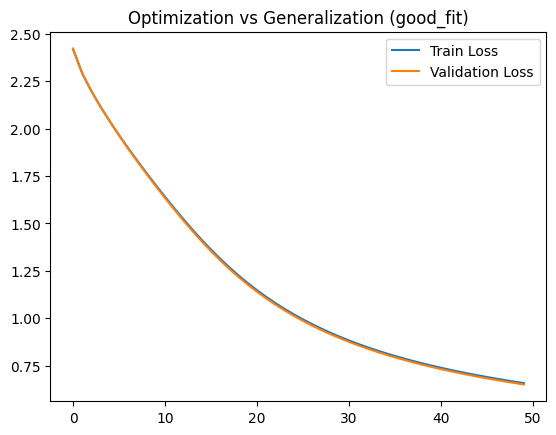

In [12]:
# =========================
# LOSS VISUALIZATION
# =========================
plt.figure()
plt.plot(losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title(f"Optimization vs Generalization ({MODE})")
plt.show()


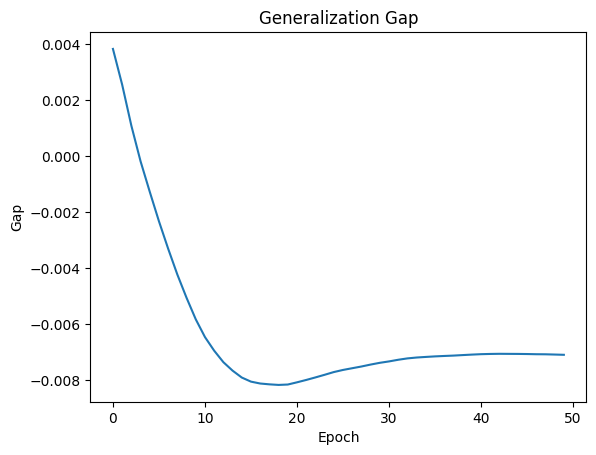

In [13]:
# =========================
# GENERALIZATION GAP
# =========================
gap = np.array(val_losses) - np.array(losses)

plt.figure()
plt.plot(gap)
plt.title("Generalization Gap")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.show()

In [14]:
# =========================
# EVALUATION
# =========================
_, _, _, preds = forward(X_test)

y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_true)
print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8519



Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       980
           1       0.89      0.95      0.92      1135
           2       0.86      0.82      0.84      1032
           3       0.82      0.87      0.85      1010
           4       0.84      0.85      0.85       982
           5       0.84      0.66      0.74       892
           6       0.87      0.88      0.88       958
           7       0.87      0.86      0.86      1028
           8       0.79      0.80      0.80       974
           9       0.83      0.83      0.83      1009

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



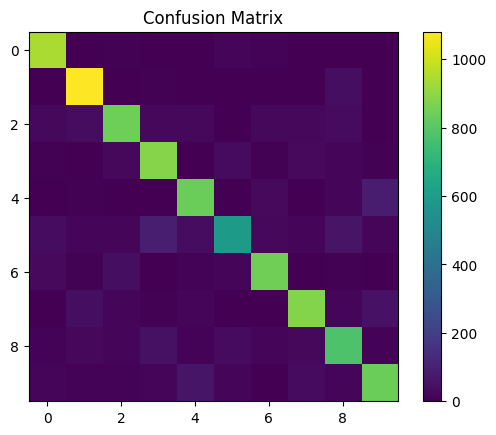

In [15]:
# =========================
# METRICS
# =========================
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

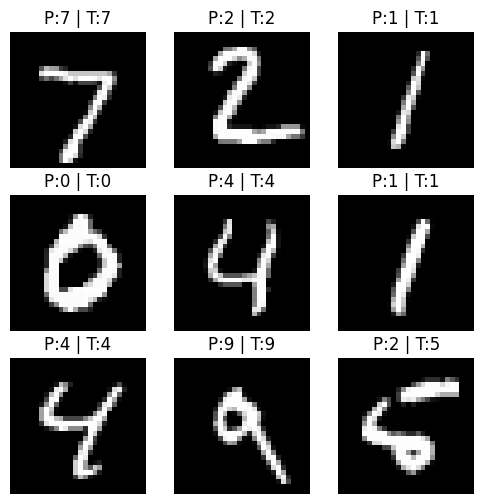

In [16]:
# =========================
# PREDICTIONS
# =========================
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{y_pred[i]} | T:{y_true[i]}")
    plt.axis('off')
plt.show()

In [17]:
# =========================
# INTERPRETATION
# =========================
print("\nINTERPRETATION:")

if MODE == "underfitting":
    print("→ Model too simple → cannot learn patterns")
elif MODE == "overfitting":
    print("→ memorizing training data")
elif MODE == "good_fit":
    print("→ balanced learning")
elif MODE == "slow_learning":
    print("→ learning too slow")

print("\nKEY IDEA:")
print("Optimization = minimizing loss")
print("Generalization = performing on unseen data")


INTERPRETATION:
→ balanced learning

KEY IDEA:
Optimization = minimizing loss
Generalization = performing on unseen data
